# Fair Feeder V13 — Full Training Pipeline

This notebook runs **entirely online** (Colab or Kaggle). No local setup needed.

**What it does:**
1. Installs dependencies
2. Downloads V13 dataset from Roboflow
3. Fixes polygon labels → bounding boxes
4. Visual verification (you check the boxes look right)
5. Trains YOLOv11 with W&B tracking + checkpoint resume
6. Reviews results and downloads trained model

**Before you start:** Make sure you have a GPU runtime enabled:
- **Colab**: Runtime → Change runtime type → T4 GPU
- **Kaggle**: Settings → Accelerator → GPU T4 x2

**If your session disconnects:** Skip to Step 5b to resume from the last checkpoint.

## Step 0 — Install Dependencies

In [1]:
!pip install -q ultralytics roboflow opencv-python-headless wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupy

## Step 1 — Set Your API Keys

Replace the placeholder values below with your actual keys.

In [2]:
ROBOFLOW_API_KEY = "PlVhVCbGGRLqGZjUMvTd"  # <-- paste your Roboflow key here
WANDB_API_KEY = "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"  # <-- paste your W&B key here (from wandb.ai/authorize)

## Step 1b — Setup W&B + Persistent Storage

This logs all metrics to W&B and saves checkpoints to Google Drive (Colab) or `/kaggle/working/` (Kaggle) so you can resume if disconnected.

In [3]:
import os
from pathlib import Path

# --- W&B login ---
os.environ["WANDB_API_KEY"] = WANDB_API_KEY
import wandb
wandb.login()
print("W&B: logged in")

# --- Persistent storage for checkpoints ---
# Check Kaggle FIRST — Kaggle has google.colab installed but drive.mount() fails there
ON_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ
ON_COLAB = not ON_KAGGLE and "COLAB_RELEASE_TAG" in os.environ

if ON_KAGGLE:
    SAVE_DIR = Path("/kaggle/working/fair-feeder-v13")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Checkpoints will save to: {SAVE_DIR}")
elif ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_DIR = Path("/content/drive/MyDrive/fair-feeder-v13")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Checkpoints will sync to Google Drive: {SAVE_DIR}")
else:
    SAVE_DIR = Path("runs/fair-feeder/v13/weights")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Checkpoints will save to: {SAVE_DIR}")

print("Setup complete.")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

W&B: logged in
Checkpoints will save to: /kaggle/working/fair-feeder-v13
Setup complete.


## Step 2 — Download V13 Dataset from Roboflow

In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("test-7vyqo").project("ir-kibble")
version = project.version(13)
dataset = version.download("yolov8")

DATASET_PATH = dataset.location
print(f"\nDataset downloaded to: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to IR-kibble-13 in yolov8:: 100%|██████████| 2620/2620 [00:00<00:00, 7627.36it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded to: /kaggle/working/IR-kibble-13


## Step 3 — Fix Labels (Polygon → Bounding Box)

Some labels from Roboflow may be polygon outlines instead of rectangles.
This converts them and verifies zero polygons remain.

In [5]:
import shutil
from pathlib import Path


def is_polygon_line(line):
    return len(line.strip().split()) > 5


def polygon_to_bbox(line):
    parts = line.strip().split()
    class_id = parts[0]
    coords = [float(v) for v in parts[1:]]
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min
    return f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"


dataset_path = Path(DATASET_PATH)
total_converted = 0

for split in ["train", "valid", "test"]:
    label_dir = dataset_path / split / "labels"
    if not label_dir.is_dir():
        print(f"[{split}] No labels directory — skipping")
        continue

    # Backup originals
    backup_dir = dataset_path / split / "labels_backup_polygon"
    if not backup_dir.exists():
        shutil.copytree(label_dir, backup_dir)
        print(f"[{split}] Backup created: {backup_dir}")

    # Convert
    split_converted = 0
    for f in sorted(label_dir.glob("*.txt")):
        lines = f.read_text().splitlines()
        new_lines = []
        for line in lines:
            if not line.strip():
                continue
            if is_polygon_line(line):
                new_lines.append(polygon_to_bbox(line))
                split_converted += 1
            else:
                new_lines.append(line.strip())
        f.write_text("\n".join(new_lines) + "\n" if new_lines else "")

    # Verify
    remaining = sum(
        1 for f in label_dir.glob("*.txt")
        for line in f.read_text().splitlines()
        if line.strip() and is_polygon_line(line)
    )
    status = "PASS" if remaining == 0 else f"FAIL ({remaining} polygons left)"
    print(f"[{split}] Converted {split_converted} polygon lines — Verification: {status}")
    total_converted += split_converted

print(f"\nTotal polygon lines converted: {total_converted}")

[train] Backup created: /kaggle/working/IR-kibble-13/train/labels_backup_polygon
[train] Converted 3249 polygon lines — Verification: PASS
[valid] Backup created: /kaggle/working/IR-kibble-13/valid/labels_backup_polygon
[valid] Converted 181 polygon lines — Verification: PASS
[test] Backup created: /kaggle/working/IR-kibble-13/test/labels_backup_polygon
[test] Converted 126 polygon lines — Verification: PASS

Total polygon lines converted: 3556


## Step 4 — Visual Label Check

Look at 12 random images with bounding boxes drawn on them.
If the boxes are sitting on the right objects, you're good to train.

**Colour legend:**
- Blue = Dan
- Orange = Sanbo
- Green = Dan_hand (paw)
- Yellow = Bowl
- Magenta = Kibble

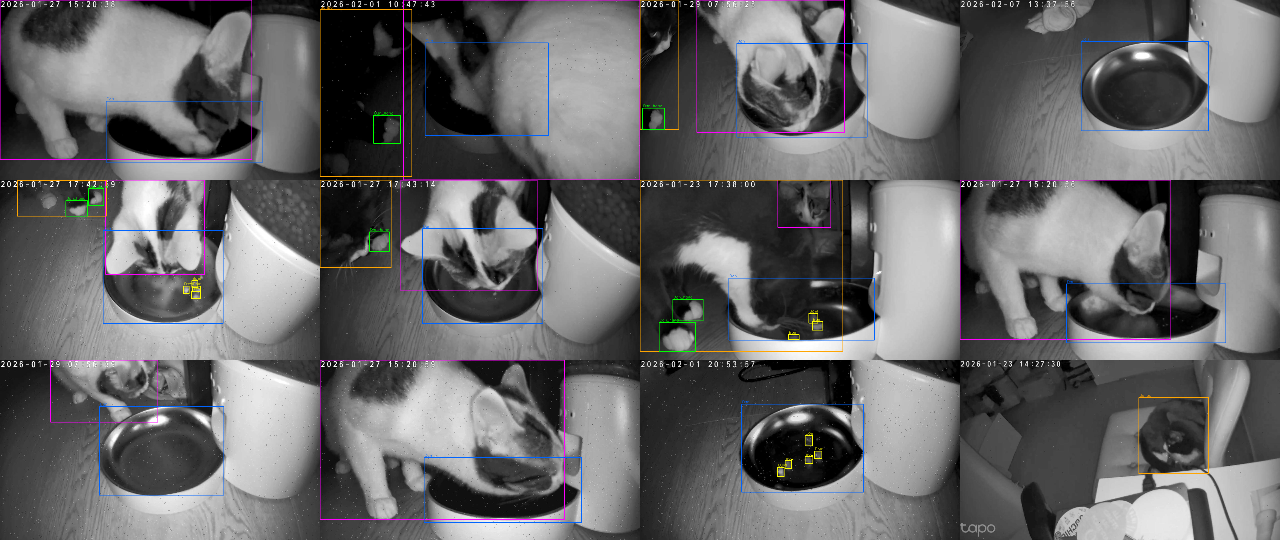


If boxes are on the right objects, proceed to training!
If something looks wrong, check your Roboflow annotations.


In [6]:
import math
import random

import cv2
import numpy as np
from IPython.display import display
from PIL import Image

CLASS_NAMES = ["Dan", "Sanbo", "Dan_hand", "Bowl", "Kibble"]
CLASS_COLORS = {
    0: (255, 100, 0),    # Dan — Blue (BGR)
    1: (0, 165, 255),    # Sanbo — Orange
    2: (0, 255, 0),      # Dan_hand — Green
    3: (0, 255, 255),    # Bowl — Yellow
    4: (255, 0, 255),    # Kibble — Magenta
}

THUMB_W, THUMB_H = 320, 180  # 16:9 to match 1280x720 source images
GRID_COLS = 4
NUM_SAMPLES = 12

image_dir = dataset_path / "train" / "images"
label_dir = dataset_path / "train" / "labels"

image_files = sorted(
    p for p in image_dir.iterdir()
    if p.suffix.lower() in (".jpg", ".jpeg", ".png")
)
sampled = random.sample(image_files, min(NUM_SAMPLES, len(image_files)))

thumbnails = []
for img_path in sampled:
    image = cv2.imread(str(img_path))
    if image is None:
        continue
    label_path = label_dir / (img_path.stem + ".txt")
    if label_path.exists():
        img_h, img_w = image.shape[:2]
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            x_ctr, y_ctr, w, h = map(float, parts[1:])
            x1 = int((x_ctr - w / 2) * img_w)
            y1 = int((y_ctr - h / 2) * img_h)
            x2 = int((x_ctr + w / 2) * img_w)
            y2 = int((y_ctr + h / 2) * img_h)
            color = CLASS_COLORS.get(cls, (255, 255, 255))
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
            cv2.putText(image, name, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    thumbnails.append(cv2.resize(image, (THUMB_W, THUMB_H)))

# Pad to fill grid
rows = math.ceil(len(thumbnails) / GRID_COLS)
while len(thumbnails) < rows * GRID_COLS:
    thumbnails.append(np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8))

grid_rows = []
for r in range(rows):
    grid_rows.append(np.hstack(thumbnails[r * GRID_COLS:(r + 1) * GRID_COLS]))
grid = np.vstack(grid_rows)

# Convert BGR → RGB for display in notebook
grid_rgb = cv2.cvtColor(grid, cv2.COLOR_BGR2RGB)
display(Image.fromarray(grid_rgb))

print("\nIf boxes are on the right objects, proceed to training!")
print("If something looks wrong, check your Roboflow annotations.")

## Step 5a — Train YOLOv11 (Fresh Start)

All V12 bug fixes baked in. W&B tracks every metric in real-time.
After training, checkpoints are copied to persistent storage.

**If disconnected:** Skip this cell and go to **Step 5b** instead.

In [7]:
import torch
from ultralytics import YOLO

# Check GPU
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = 0
else:
    print("WARNING: No GPU detected! Training will be very slow.")
    print("Enable GPU: Colab → Runtime → Change runtime type → T4 GPU")
    device = "cpu"

# Use the data.yaml that Roboflow downloaded with the dataset
data_yaml = str(dataset_path / "data.yaml")
print(f"Dataset config: {data_yaml}")

# Enable W&B logging for YOLO
os.environ["WANDB_PROJECT"] = "Fair-Feeder-YOLO11"
os.environ["WANDB_ENTITY"] = "iknoest-hknlpost"

GPU: Tesla T4
Dataset config: /kaggle/working/IR-kibble-13/data.yaml


In [8]:
import shutil

model = YOLO("yolo11s.pt")

results = model.train(
    data=data_yaml,
    imgsz=[1280, 720],         # Exact Roboflow export size (16:9) — no resize distortion
    rect=True,                 # Batches by aspect ratio — no letterbox padding

    # Geometric augmentations
    fliplr=0.5,             # Horizontal flip
    flipud=0.0,             # OFF — fixed overhead camera
    degrees=0.0,            # Rotation OFF — V12 root cause of coordinate drift

    # Colour — only brightness matters for IR grayscale
    hsv_h=0.0,              # OFF — no hue in grayscale
    hsv_s=0.0,              # OFF — no saturation in grayscale
    hsv_v=0.25,             # ON  — random brightness variation

    # Advanced augmentations
    mosaic=1.0,             # Combines 4 images — good for small objects
    copy_paste=0.3,         # Kibble class balancing
    mixup=0.0,              # OFF — destroys small kibble detail

    # Training config
    batch=8,
    epochs=100,
    patience=20,            # Early stopping if no improvement for 20 epochs
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    # Output
    project="runs/fair-feeder",
    name="v13",
    device=device,
    verbose=True,
    plots=True,
)

# Copy checkpoints to persistent storage (survives disconnect)
weights_dir = Path("runs/fair-feeder/v13/weights")
if weights_dir.exists():
    for pt_file in weights_dir.glob("*.pt"):
        shutil.copy2(pt_file, SAVE_DIR / pt_file.name)
    print(f"\nCheckpoints saved to: {SAVE_DIR}")
    for f in sorted(SAVE_DIR.glob("*.pt")):
        print(f"  {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")

print("\nTraining complete! Check W&B for full metrics.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/IR-kibble-13/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.25, imgsz=[1280, 720], int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v13, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, 

## Step 5b — Resume Training After Disconnect (auto-skips on first run)

In [9]:
import shutil
from ultralytics import YOLO

# Auto-skip if training already completed (first run via "Run All")
best_pt = SAVE_DIR / "best.pt"
last_pt = SAVE_DIR / "last.pt"

if best_pt.exists() and not last_pt.exists():
    print("Training already completed — skipping resume.")
elif not last_pt.exists():
    print("No checkpoint found — skipping (run Step 5a first).")
else:
    # Restore checkpoint to local working directory
    local_weights = Path("runs/fair-feeder/v13/weights")
    local_weights.mkdir(parents=True, exist_ok=True)
    shutil.copy2(last_pt, local_weights / "last.pt")
    print(f"Restored checkpoint from: {last_pt}")

    model = YOLO(str(local_weights / "last.pt"))
    results = model.train(resume=True)

    # Save final checkpoints back to persistent storage
    for pt_file in local_weights.glob("*.pt"):
        shutil.copy2(pt_file, SAVE_DIR / pt_file.name)
    print(f"\nFinal checkpoints saved to: {SAVE_DIR}")
    print("Training complete! Check W&B for full metrics.")

No checkpoint found — skipping (run Step 5a first).


## Step 6 — Review Results

Check the training metrics and confusion matrix.

In [10]:
from IPython.display import Image as IPImage, display

results_dir = Path("runs/fair-feeder/v13")

# Show confusion matrix
confusion_matrix = results_dir / "confusion_matrix.png"
if confusion_matrix.exists():
    print("Confusion Matrix:")
    display(IPImage(filename=str(confusion_matrix)))

# Show training curves
results_plot = results_dir / "results.png"
if results_plot.exists():
    print("\nTraining Curves:")
    display(IPImage(filename=str(results_plot)))

# Show best model path
best_model = results_dir / "weights" / "best.pt"
if best_model.exists():
    print(f"\nBest model saved at: {best_model}")
    print(f"Model size: {best_model.stat().st_size / 1024 / 1024:.1f} MB")
    print("\nDownload this file to use in your Fair Feeder application.")

## Step 7 — Download Your Trained Model

Run this cell to download the `best.pt` model file to your computer.

In [11]:
import os

best_model = Path("runs/fair-feeder/v13/weights/best.pt")

if not best_model.exists():
    print("Model not found — make sure training completed successfully.")
else:
    # Detect platform and trigger download
    if "COLAB_RELEASE_TAG" in os.environ:
        from google.colab import files
        files.download(str(best_model))
        print("Download started (check your browser downloads).")
    elif "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
        # On Kaggle, save to /kaggle/working/ for the Output tab
        import shutil
        output_path = Path("/kaggle/working/best.pt")
        shutil.copy2(best_model, output_path)
        print(f"Model copied to {output_path}")
        print("Go to the Output tab to download it.")
    else:
        print(f"Model is at: {best_model}")
        print(f"Size: {best_model.stat().st_size / 1024 / 1024:.1f} MB")

Model not found — make sure training completed successfully.
